# Attention Map Capture & Quick Interpretability

In [ ]:
!pip install torch transformers matplotlib pillow pandas hf_transfer einops

## 1. Imports + Dry runs
Let's use `llava-1.5-7b` for preliminary analysis

In [2]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [3]:
from transformers import AutoProcessor, LlavaForConditionalGeneration

model = LlavaForConditionalGeneration.from_pretrained("llava-hf/llava-1.5-7b-hf", dtype=torch.bfloat16, device_map=DEVICE, attn_implementation="eager")
processor = AutoProcessor.from_pretrained("llava-hf/llava-1.5-7b-hf", use_fast=True)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [4]:
IMAGE_PATH = "../assets/room.png"
PROMPT = "What is shown in this image?"

conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": IMAGE_PATH},
            {"type": "text", "text": PROMPT},
        ],
    },
]
inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt"
).to(DEVICE, torch.bfloat16)

generate_ids = model.generate(**inputs, max_new_tokens=30, output_attentions=True)
processor.batch_decode(generate_ids, skip_special_tokens=True)

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


['USER:  \nWhat is shown in this image? ASSISTANT: The image shows a large, modern living room with a clean and minimalist design. The room features a flat screen TV, a couch, a']

## 2. Understanding Input IDs

We need to know which are the image tokens, and which is the text query token we gotta pick as the attention source

### Token IDs we supply to the model

In [5]:
# first 30 token IDs we supply to the model
inputs['input_ids'][0][:30]

tensor([    1,  3148,  1001, 29901, 29871, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000],
       device='mps:0')

In [6]:
# last 30 token IDs we supply to the model
inputs['input_ids'][0][-30:]

tensor([32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000, 32000,
        32000, 32000, 32000, 32000, 32000, 32000, 29871,    13,  5618,   338,
         4318,   297,   445,  1967, 29973,   319,  1799,  9047, 13566, 29901],
       device='mps:0')

In [7]:
# full input IDs length
inputs['input_ids'].shape # [batch_size, sequence_length]

torch.Size([1, 595])

### Tokenizer and `<image>` token

In [8]:
processor.tokenizer

LlamaTokenizerFast(name_or_path='llava-hf/llava-1.5-7b-hf', vocab_size=32000, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'image_token': '<image>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32000: AddedToken("<image>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32001: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [9]:
print(processor.tokenizer.convert_tokens_to_ids('<image>'))
print(processor.tokenizer.decode(32000))
# now we know why there are so many 32000s in the input IDs, because those are the image tokens


32000
<image>


## 3. Understanding how they preprocess from image to `<image>` token
They will patchify the big image into smaller patches, and then tokenizer them into `<image>` tokens. We will see how they go from big, arbitrary image size to exactly 576 `image` tokens

(700, 505)


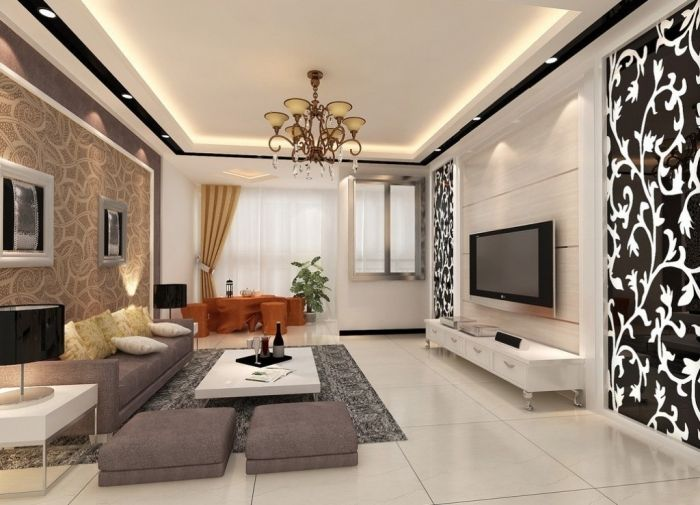

In [10]:
from PIL import Image

img = Image.open(IMAGE_PATH)
# let's see the original image size
print(img.size)
# its arbitrary and far from any predefined size
img

In [11]:
# see that vision encoder config has ["image_size"] at 336x336, and then patchified into 14x14 patches, the number of patches will be (336 / 14) ** 2 = 576 patches
model.vision_tower.config

CLIPVisionConfig {
  "attention_dropout": 0.0,
  "dtype": "bfloat16",
  "hidden_act": "quick_gelu",
  "hidden_size": 1024,
  "image_size": 336,
  "initializer_factor": 1.0,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "layer_norm_eps": 1e-05,
  "model_type": "clip_vision_model",
  "num_attention_heads": 16,
  "num_channels": 3,
  "num_hidden_layers": 24,
  "patch_size": 14,
  "projection_dim": 768,
  "transformers_version": "4.57.1",
  "vocab_size": 32000
}

In [12]:
# So now, it resizes the image by using the tokenizer into such size
inputs = processor.apply_chat_template(
    conversation,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt"
).to(DEVICE, torch.bfloat16)
print('BEFORE:', img.size)
print('AFTER:', inputs["pixel_values"].shape) # [batch_size, RGB channel, resized_image, resized_image]

BEFORE: (700, 505)
AFTER: torch.Size([1, 3, 336, 336])


In [13]:
# more over, this 336x336 will be patchified into 14x14 patches, the number of patches will be (336 / 14) ** 2 = 576 patches
decoded_text = processor.tokenizer.decode(inputs['input_ids'][0][:10], skip_special_tokens=False) + "......" +  processor.tokenizer.decode(inputs['input_ids'][0][-20:])
print(decoded_text)

# each patch will be represented by a `<image>` token, and there are 576 patches, so there will be 576 `<image>` tokens
print()
print(f"Count <image> tokens: {processor.tokenizer.decode(inputs['input_ids'][0]).count('<image>')}")

<s> USER: <image><image><image><image><image>......<image><image><image><image><image><image> 
What is shown in this image? ASSISTANT:

Count <image> tokens: 576


## 4. Storing the query and `<image>` idx

Image token indices in original input IDs

In [14]:
# lets capture the index of image token and also the text query token (not including the system tokens like <s>, <pad>, <eot>, etc.) so we can know which position to attend from text to image.
image_token_idxs = [i for i, token_id in enumerate(inputs['input_ids'][0]) if token_id == processor.tokenizer.convert_tokens_to_ids('<image>')]

assert len(image_token_idxs) == (model.vision_tower.config.image_size // model.vision_tower.config.patch_size) ** 2
print(f"Image token [start, end]: ({image_token_idxs[0]}, {image_token_idxs[-1]})")


Image token [start, end]: (5, 580)


Text query token indices in original input IDs

In [15]:
query_token_ids = processor.tokenizer.encode("\nWhat is shown in this image?") # if u dont add \n, 'What' will be encoded as 1724, there is another mid-sentence 'What' token encoded as 5618, which we want that.
print("Token IDs:", query_token_ids)
print("Decoded tokens:", processor.tokenizer.decode(query_token_ids))

# lets trim the <s> and \n start token so we get the pure query text token IDs
query_token_ids = query_token_ids[3:]

print()
print("Token IDs (after <s> trimming):", query_token_ids)
print("Decoded tokens (after <s> trimming):", processor.tokenizer.decode(query_token_ids))

Token IDs: [1, 29871, 13, 5618, 338, 4318, 297, 445, 1967, 29973]
Decoded tokens: <s> 
What is shown in this image?

Token IDs (after <s> trimming): [5618, 338, 4318, 297, 445, 1967, 29973]
Decoded tokens (after <s> trimming): What is shown in this image?


In [16]:
import torch

query = torch.tensor(query_token_ids, device=DEVICE)
n = query.size(0)

windows = inputs['input_ids'][0].unfold(0, n, 1)
match_mask = (windows == query).all(dim=1)

starts = match_mask.nonzero(as_tuple=True)[0].item()
ends = starts + n - 1

text_token_idxs = [i for i in range(starts, ends + 1)]
print("Text token [start, end]:", starts, ends)

Text token [start, end]: 583 589


## 5. Attention heatmap of LLaVA's middle layers into each text query token
Prior works (todo pls cite) showed that middle layers work the best to give best pointing visual attention signal, lets extract Q1-Q3 layers and average them out for each text query token

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math

In [20]:
def generate_with_attn(model, processor, image_path, question, final_answer_tokens=50):
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text", "text": question},
            ],
        },
    ]

    inputs = processor.apply_chat_template(
        conversation,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    ).to(DEVICE, torch.bfloat16)

    with torch.no_grad():
        gen_output = model.generate(
            **inputs,
            max_new_tokens=final_answer_tokens,
            do_sample=False,
            output_attentions=True,
            return_dict_in_generate=True
        )

    input_ids = inputs['input_ids'][0].tolist()
    gen_ids = gen_output.sequences
    trimmed_ids = [out[len(inp):] for inp, out in zip(inputs.input_ids, gen_ids)]
    output_text = processor.batch_decode(trimmed_ids, skip_special_tokens=True)[0].strip()
    
    # Find image token indices
    image_token_id = processor.tokenizer.convert_tokens_to_ids("<image>")
    image_token_idxs = [i for i, id in enumerate(input_ids) if id == image_token_id]
    
    # Find text query token indices
    query_token_ids = processor.tokenizer.encode("\n" + question)[3:]  # Trim the <s> and \n start token
    n = len(query_token_ids)
    windows = torch.tensor(input_ids, device=DEVICE).unfold(0, n, 1)
    match_mask = (windows == torch.tensor(query_token_ids, device=DEVICE)).all(dim=1)
    starts = match_mask.nonzero(as_tuple=True)[0].item()
    ends = starts + n - 1
    text_token_idxs = list(range(starts, ends + 1))
    
    # Find output token indices
    output_ids = gen_ids[0].tolist()
    output_token_idxs = list(range(len(input_ids), len(output_ids)))

    return output_text, gen_output.attentions, input_ids, output_ids, inputs['pixel_values'], image_token_idxs, text_token_idxs, output_token_idxs

In [ ]:
def visualize_text_to_image_attention(
    attentions,
    input_ids,
    output_ids,
    pixel_values,
    processor,
    image_token_idxs,
    text_token_idxs,
    output_token_idxs,
    start_layer=15,
    end_layer=25,
    device=DEVICE,
    global_vmax=0.005,
    show_averages=True,
    capture_attn_matrix=None # [i/o, which index]
):
    selected_layers = list(range(start_layer, end_layer + 1))
    num_text_tokens = len(text_token_idxs)
    num_image_tokens = len(image_token_idxs)
    num_output_tokens = len(output_token_idxs)
    grid_size = int(math.sqrt(num_image_tokens))

    # Decode each output token individually
    def decode_token(tok_id):
        tok_str = processor.tokenizer.decode([tok_id], skip_special_tokens=True)
        if tok_str.strip() == "":
            tok_str = processor.tokenizer.convert_ids_to_tokens(tok_id)
        return tok_str

    output_token_texts = [decode_token(tok) for tok in output_ids[len(input_ids):]]

    # Figure setup
    total_slots = num_text_tokens + num_output_tokens + (3 if show_averages else 0)
    fig_size = int(math.sqrt(total_slots)) + 1
    fig, axes = plt.subplots(fig_size, fig_size, figsize=(18, 18))
    axes = axes.flatten()

    # Prepare image
    image_tensor = pixel_values[0].cpu().permute(1, 2, 0)
    image_np = image_tensor.to(torch.float32).numpy()
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())
    h_ratio = image_np.shape[0] / grid_size
    w_ratio = image_np.shape[1] / grid_size

    input_token_maps = []
    output_token_maps = []

    # ==========================================================
    # INPUT TOKENS → IMAGE
    # ==========================================================
    for i, token_idx in enumerate(text_token_idxs):
        if i >= len(axes):
            break

        token_text = processor.tokenizer.decode([input_ids[token_idx]])
        avg_attn = torch.zeros(len(input_ids), device=device)

        for layer_idx in selected_layers:
            attn_weights = attentions[0][layer_idx][0]  # [heads, q_len, k_len]
            avg_attn += attn_weights.mean(dim=0)[token_idx]
        avg_attn /= len(selected_layers)

        image_attn = avg_attn[image_token_idxs].to(torch.float32).cpu().numpy().reshape(grid_size, grid_size)
        input_token_maps.append(image_attn)

        # visualize
        full_map = np.zeros((image_np.shape[0], image_np.shape[1]))
        for h in range(grid_size):
            for w in range(grid_size):
                h_start, h_end = int(h * h_ratio), int((h + 1) * h_ratio)
                w_start, w_end = int(w * w_ratio), int((w + 1) * w_ratio)
                full_map[h_start:h_end, w_start:w_end] = image_attn[h, w]

        axes[i].imshow(image_np)
        axes[i].imshow(full_map, cmap="viridis", alpha=0.7, vmin=0, vmax=global_vmax)
        axes[i].set_title(f"In: #{i} {token_text}", fontsize=9)
        axes[i].axis("off")

    # ==========================================================
    # OUTPUT TOKENS → IMAGE
    # ==========================================================
    for t, layer_attentions in enumerate(attentions):
        if num_text_tokens + t >= len(axes):
            break

        avg_attn = None
        for layer_idx in selected_layers:
            attn_weights = layer_attentions[layer_idx][0]  # [heads, q_len, k_len]
            attn_mean = attn_weights.mean(dim=0)[0]
            attn_mean = attn_mean[:len(input_ids)]  # crop to input (avoid mismatch)
            avg_attn = attn_mean if avg_attn is None else avg_attn + attn_mean
        avg_attn /= len(selected_layers)

        image_attn = avg_attn[image_token_idxs].to(torch.float32).cpu().numpy().reshape(grid_size, grid_size)
        output_token_maps.append(image_attn)

        # visualize
        full_map = np.zeros((image_np.shape[0], image_np.shape[1]))
        for h in range(grid_size):
            for w in range(grid_size):
                h_start, h_end = int(h * h_ratio), int((h + 1) * h_ratio)
                w_start, w_end = int(w * w_ratio), int((w + 1) * w_ratio)
                full_map[h_start:h_end, w_start:w_end] = image_attn[h, w]

        token_label = output_token_texts[t] if t < len(output_token_texts) else f"<unk>"
        axes[num_text_tokens + t].imshow(image_np)
        axes[num_text_tokens + t].imshow(full_map, cmap="viridis", alpha=0.7, vmin=0, vmax=global_vmax)
        axes[num_text_tokens + t].set_title(f"Out: #{t} {token_label}", fontsize=9, color='red')
        axes[num_text_tokens + t].axis("off")

    # ==========================================================
    # AVERAGE MAPS
    # ==========================================================
    next_idx = num_text_tokens + num_output_tokens

    def plot_avg(title, maps, ax):
        if not maps:
            return
        avg_map = np.mean(maps, axis=0)
        full_map = np.zeros((image_np.shape[0], image_np.shape[1]))
        for h in range(grid_size):
            for w in range(grid_size):
                h_start, h_end = int(h * h_ratio), int((h + 1) * h_ratio)
                w_start, w_end = int(w * w_ratio), int((w + 1) * w_ratio)
                full_map[h_start:h_end, w_start:w_end] = avg_map[h, w]
        ax.imshow(image_np)
        ax.imshow(full_map, cmap="viridis", alpha=0.7, vmin=0, vmax=global_vmax)
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    if show_averages:
        if input_token_maps and next_idx < len(axes):
            plot_avg("Avg input tokens", input_token_maps, axes[next_idx])
            next_idx += 1
        if output_token_maps and next_idx < len(axes):
            plot_avg("Avg output tokens", output_token_maps, axes[next_idx])
            next_idx += 1
        if input_token_maps and output_token_maps and next_idx < len(axes):
            plot_avg("Avg all tokens", input_token_maps + output_token_maps, axes[next_idx])
            next_idx += 1

    # turn off unused
    for i in range(next_idx, len(axes)):
        axes[i].axis("off")

    plt.tight_layout(rect=[0, 0.02, 1, 0.95])
    plt.suptitle(
        f"Input/Output Tokens → Image Attention (layers {start_layer}-{end_layer})\n{question}",
        fontsize=16, y=0.995
    )
    plt.subplots_adjust(top=0.93, bottom=0.03)
    plt.show()

    attn_matrix = None
    if capture_attn_matrix:
        if capture_attn_matrix[0] == "i":
            attn_matrix = input_token_maps[capture_attn_matrix[-1]].astype(np.float16)
        elif capture_attn_matrix[0] == "o":
            attn_matrix = output_token_maps[capture_attn_matrix[-1]].astype(np.float16)
    return attn_matrix

### Example 1: TV

In this room, people can drink from the wine glasses that are placed on the coffee table. The presence of multiple wine glasses suggests that the room is designed for socializing and entertaining guests. The guests can enjoy their drinks while sitting


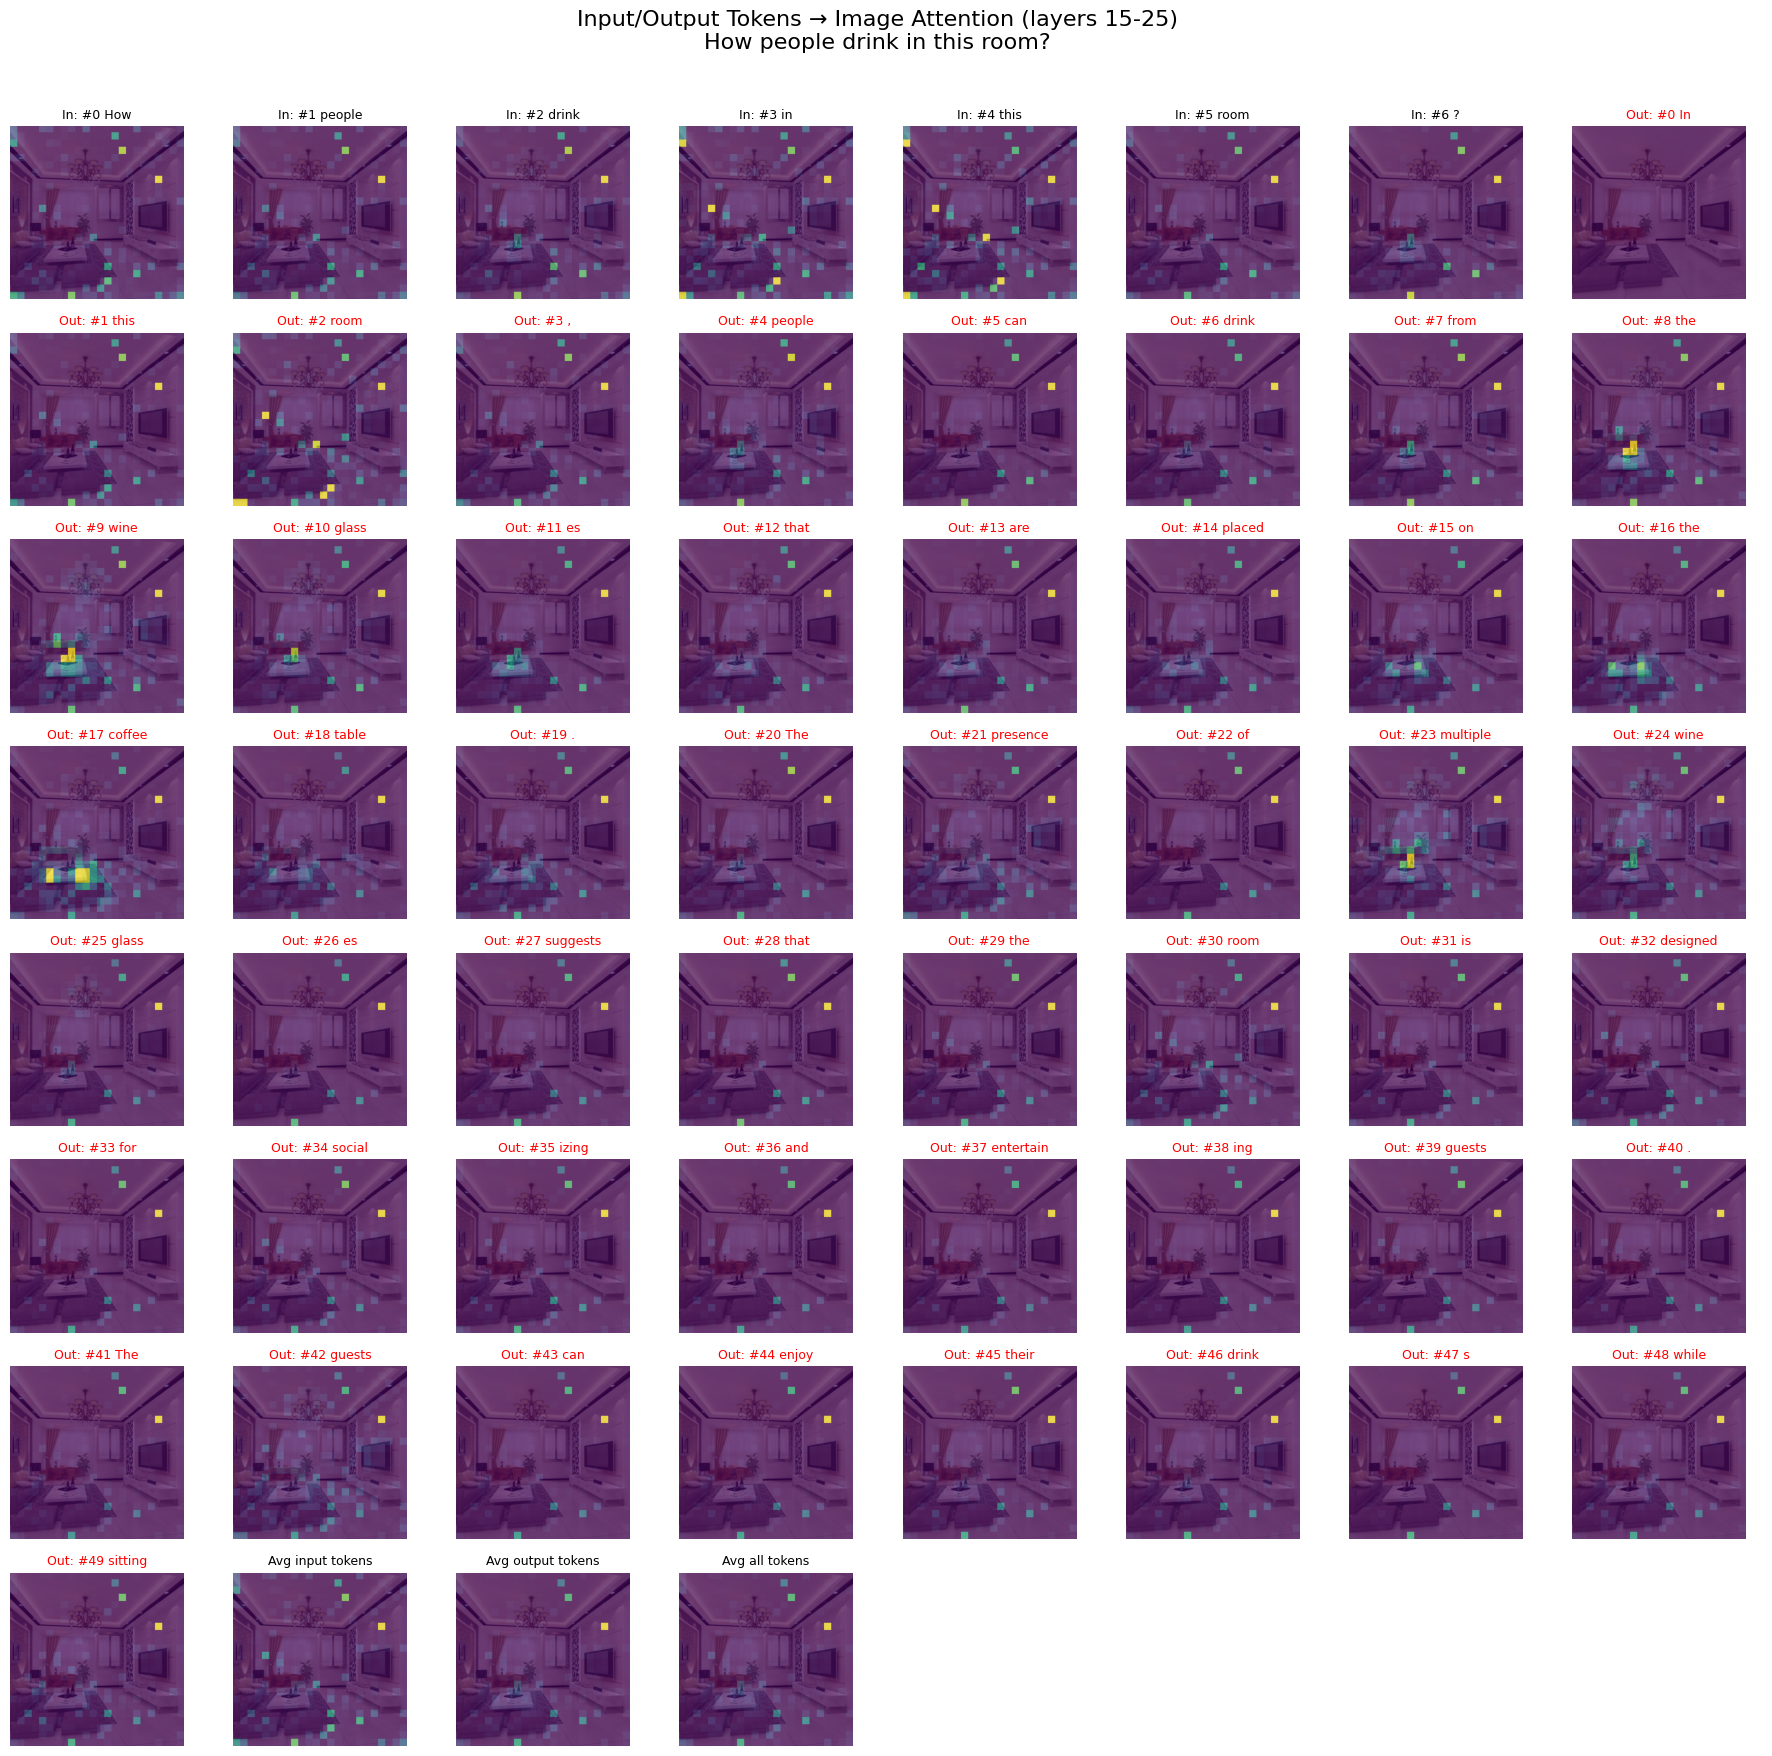

In [ ]:
question = "How people drink in this room?"
response, attentions, input_ids, output_ids, pixel_values, image_token_idxs, text_token_idxs, output_token_idxs = generate_with_attn(model, processor, IMAGE_PATH, question)
print(response)

attn_matrix = visualize_text_to_image_attention(
    attentions,
    input_ids,
    output_ids,
    pixel_values,
    processor,
    image_token_idxs,
    text_token_idxs,
    output_token_idxs,
    start_layer=15,
    end_layer=25,
    device=DEVICE,
)

### Example 2: Mat, Floor, Coffee Table

The floor objects in the image are a couch and a coffee table.


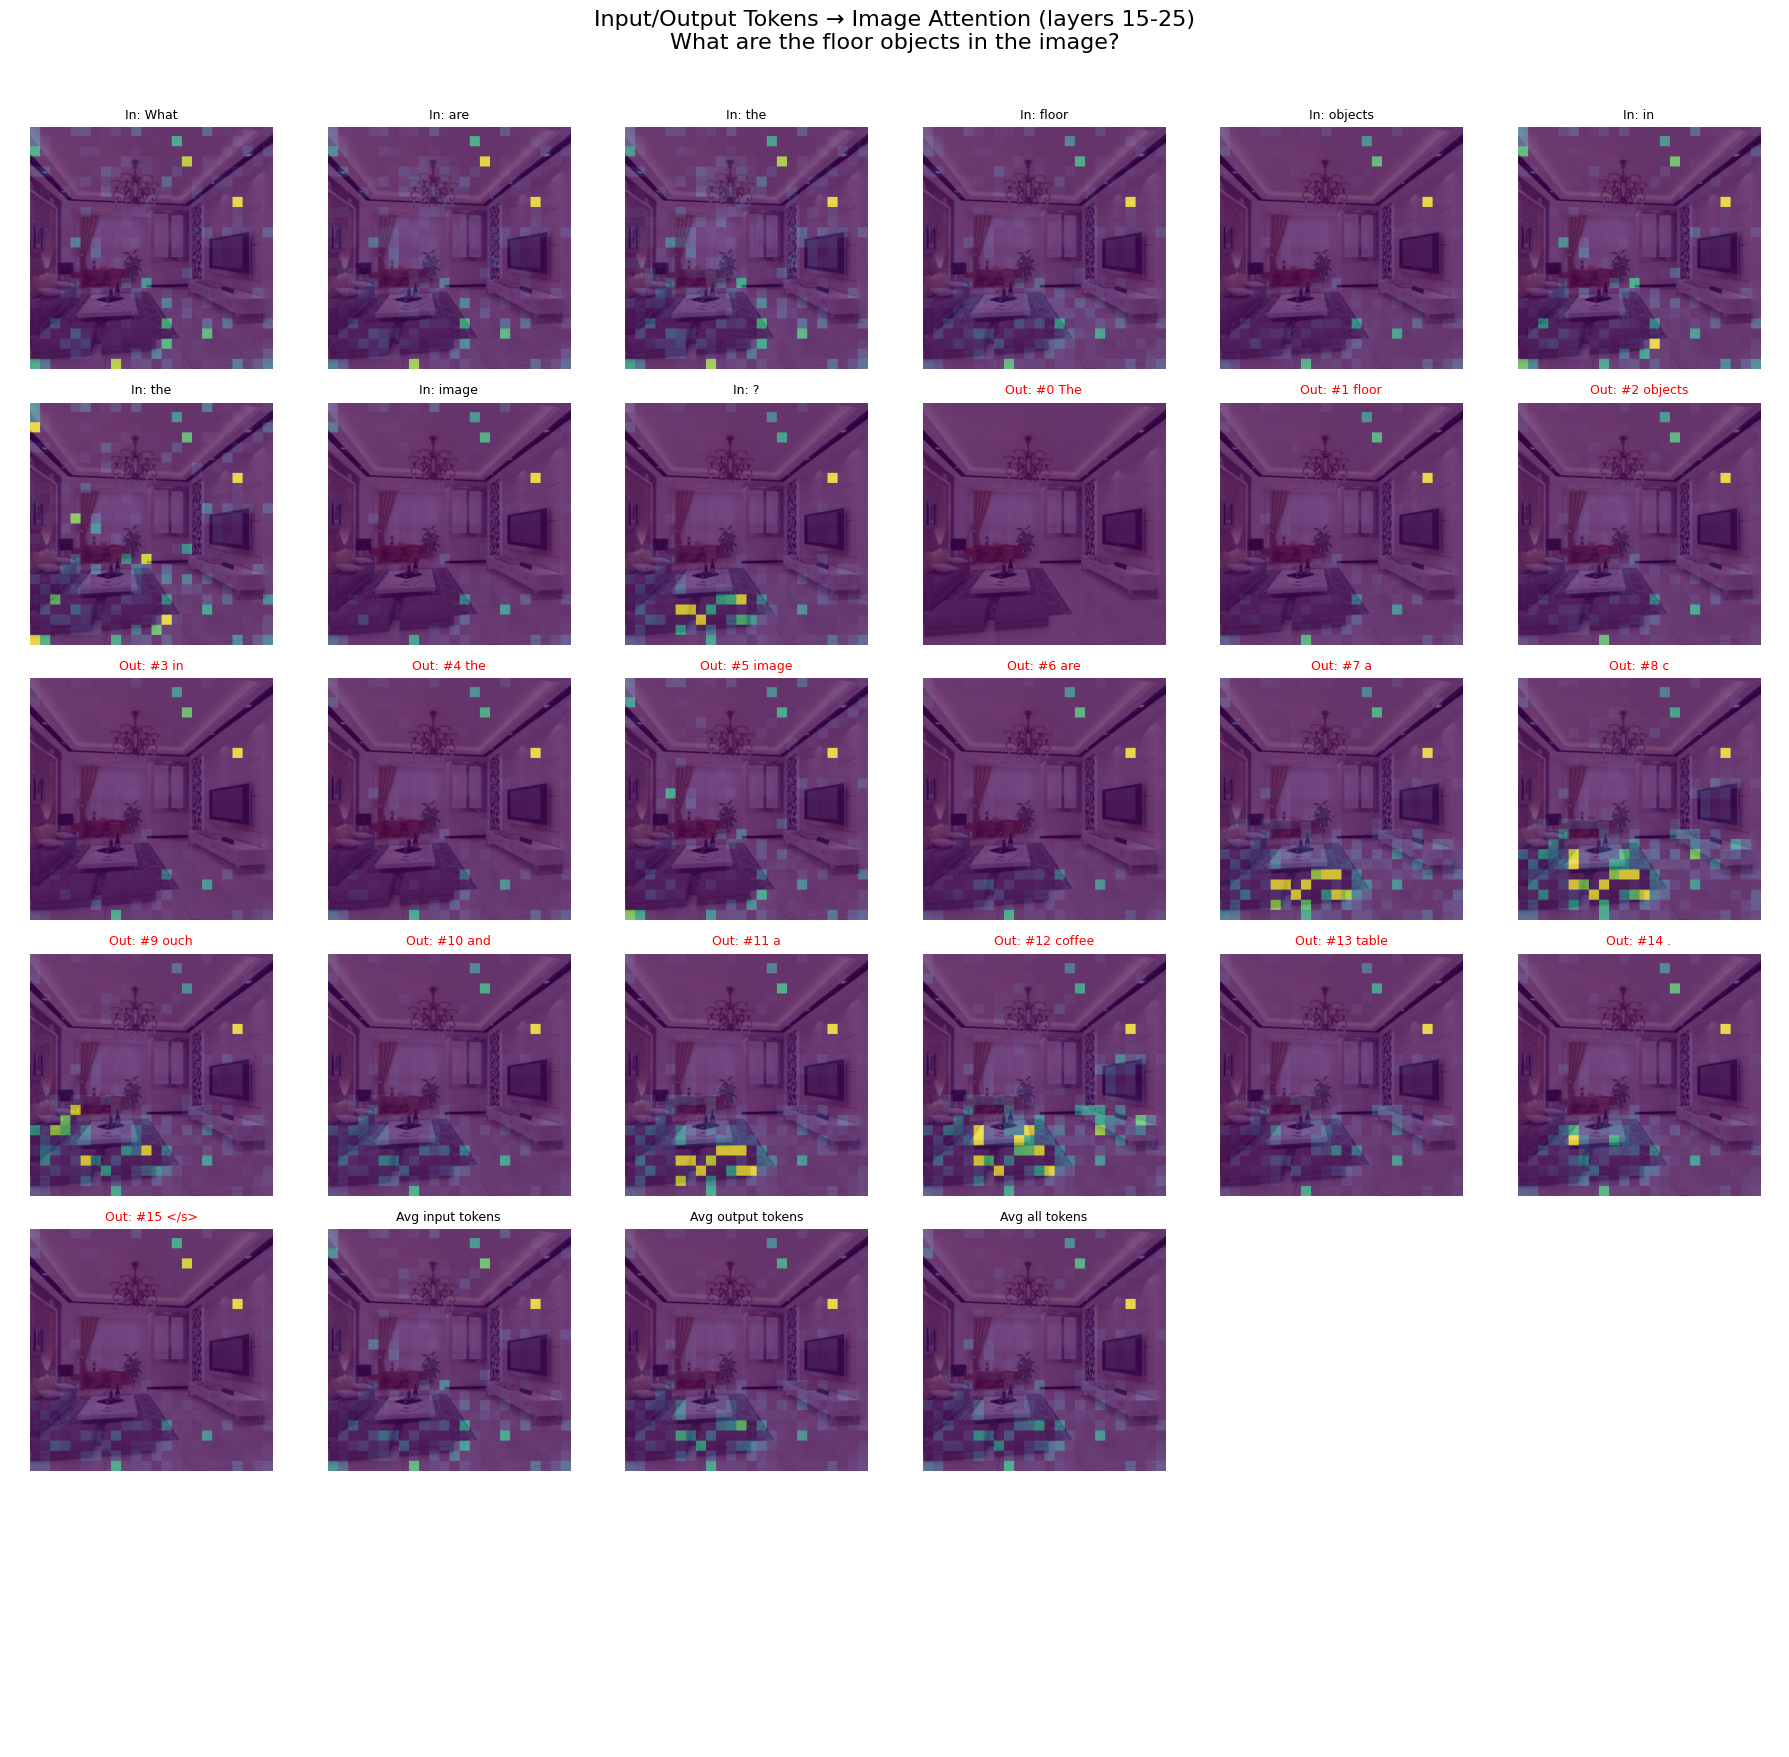

In [ ]:
question = "What are the floor objects in the image?"
response, attentions, input_ids, output_ids, pixel_values, image_token_idxs, text_token_idxs, output_token_idxs = generate_with_attn(model, processor, IMAGE_PATH, question)
print(response)

attn_matrix = visualize_text_to_image_attention(
    attentions,
    input_ids,
    output_ids,
    pixel_values,
    processor,
    image_token_idxs,
    text_token_idxs,
    output_token_idxs,
    start_layer=15,
    end_layer=25,
    device=DEVICE,
)

### Example 3: Dark Colored Objects

In the image, there are a few dark colored objects. A large TV is placed on a white stand, and a couch is located in the living room. Additionally, there is a potted plant, a vase, and a bottle


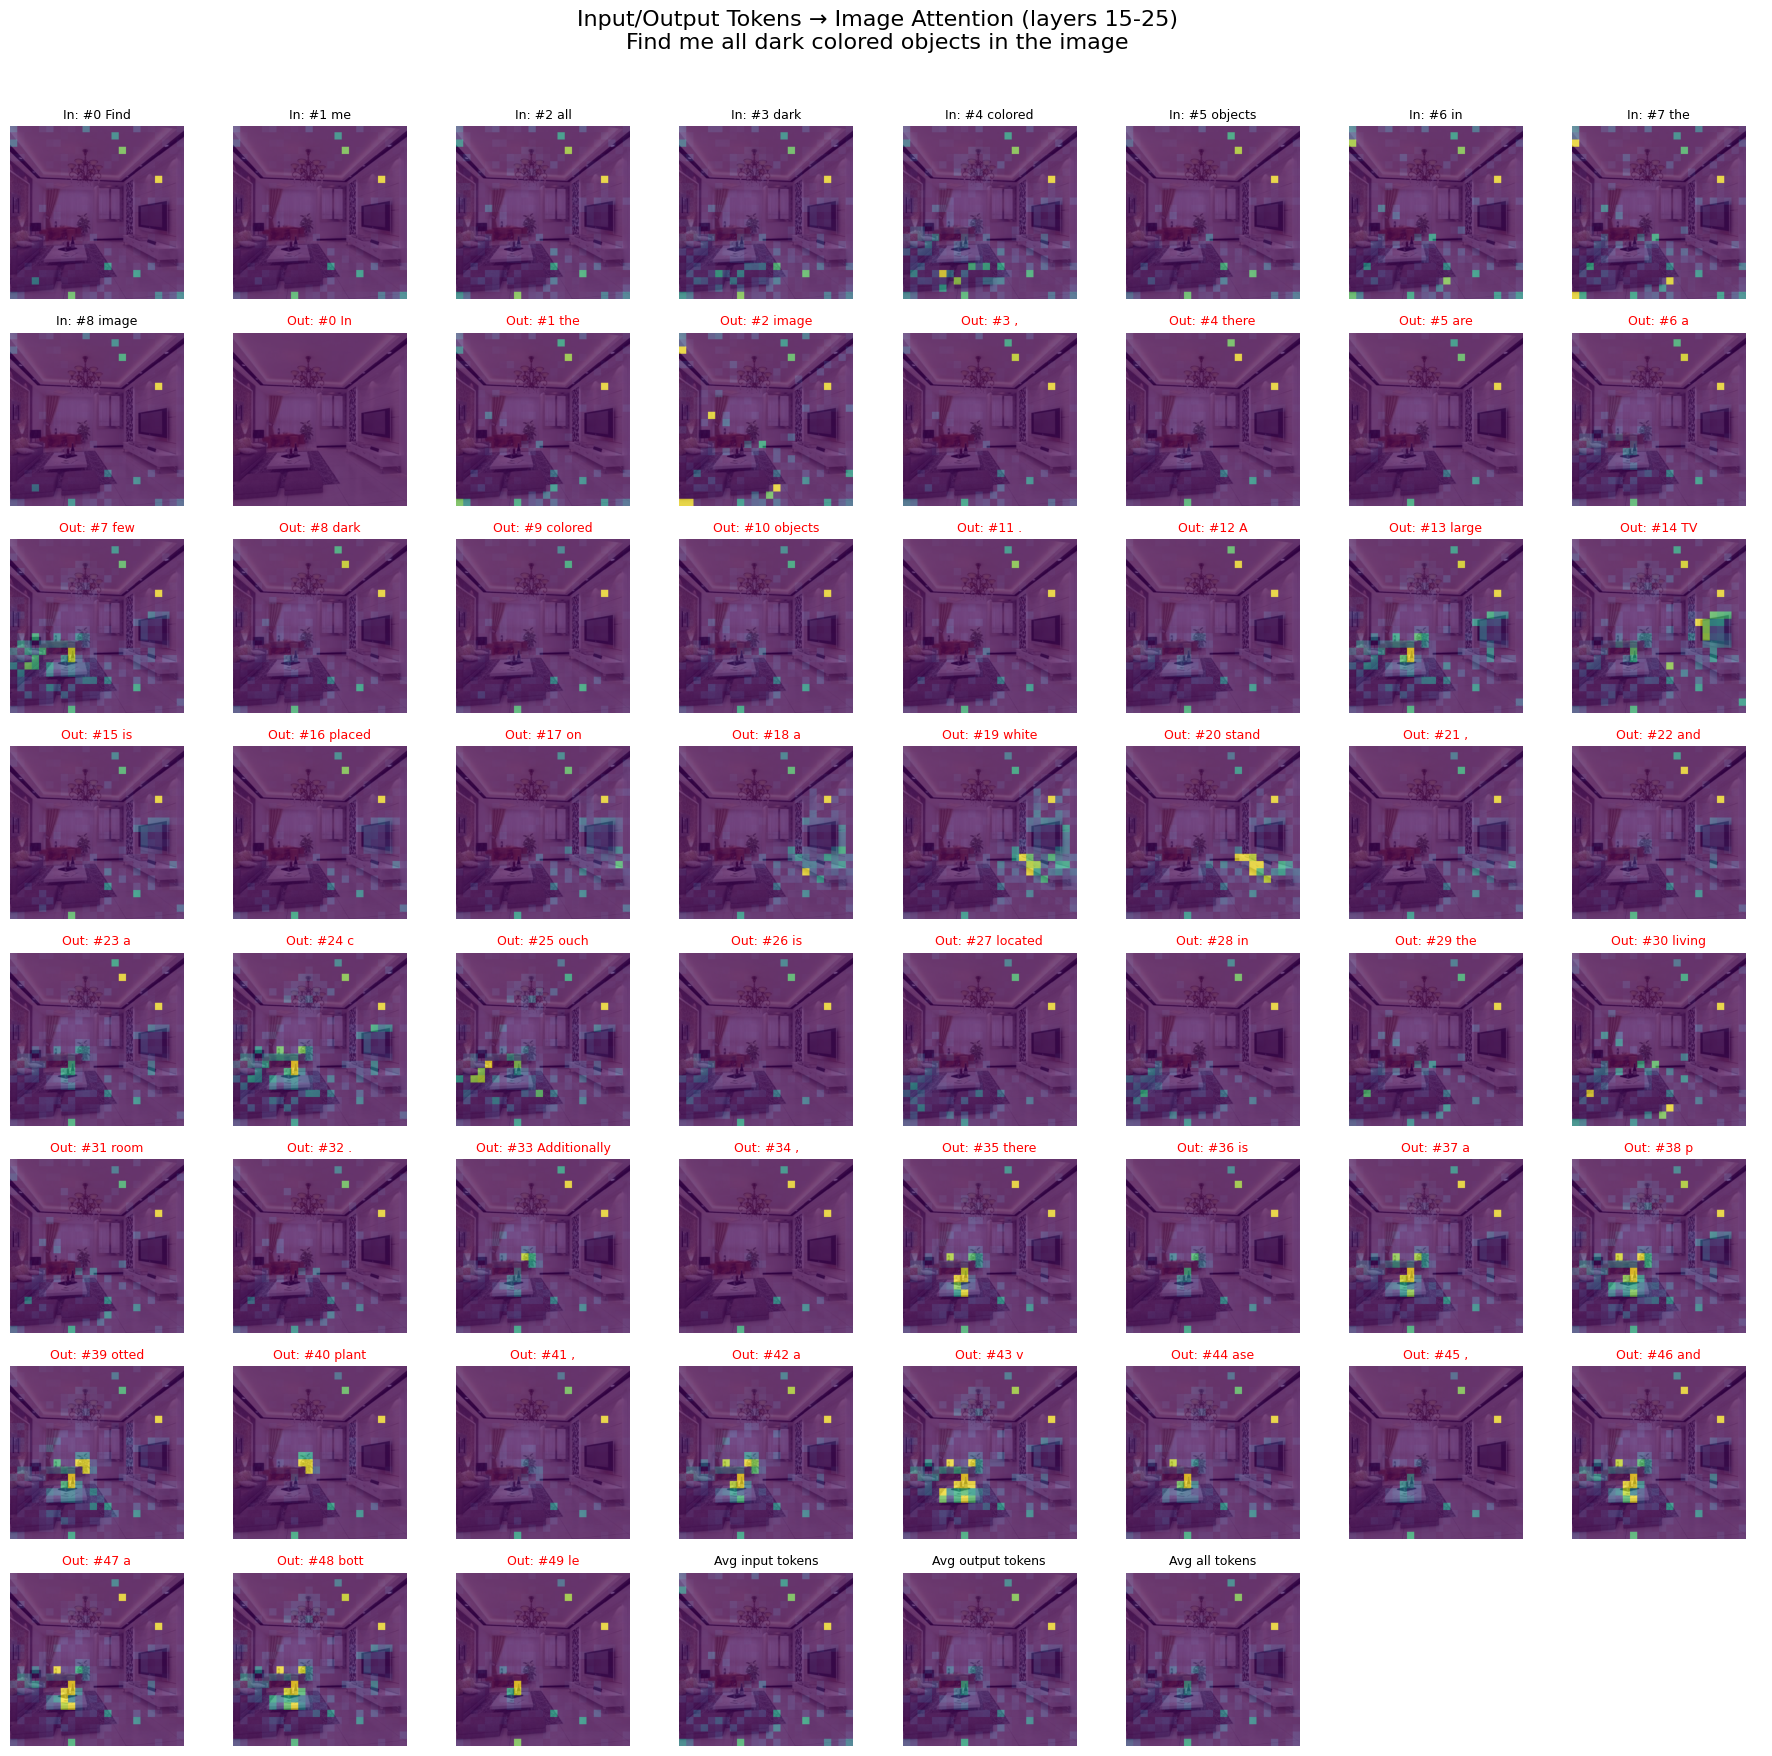

In [83]:
question = "Find me all dark colored objects in the image"
response, attentions, input_ids, output_ids, pixel_values, image_token_idxs, text_token_idxs, output_token_idxs = generate_with_attn(model, processor, IMAGE_PATH, question)
print(response)

attn_matrix = visualize_text_to_image_attention(
    attentions,
    input_ids,
    output_ids,
    pixel_values,
    processor,
    image_token_idxs,
    text_token_idxs,
    output_token_idxs,
    start_layer=15,
    end_layer=25,
    device=DEVICE,
    capture_attn_matrix=["o",14]
)

## 6. Revisualizing the specific attn matrix

In [84]:
def visualize_attention_heatmap(attn_matrix, image, alpha=0.7, cmap='viridis'):
    img_w, img_h = image.size
    if hasattr(attn_matrix, 'cpu'):
        attn_matrix = attn_matrix.cpu().numpy()
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(image)
    
    target_size = min(img_w, img_h)
    x_offset = (img_w - target_size) // 2
    y_offset = (img_h - target_size) // 2
    
    vmax = np.max(attn_matrix) * 0.7
    heatmap = ax.imshow(attn_matrix, alpha=alpha, cmap=cmap, vmax=vmax,
                       extent=[x_offset, x_offset + target_size, y_offset + target_size, y_offset],
                       interpolation='nearest')
    
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

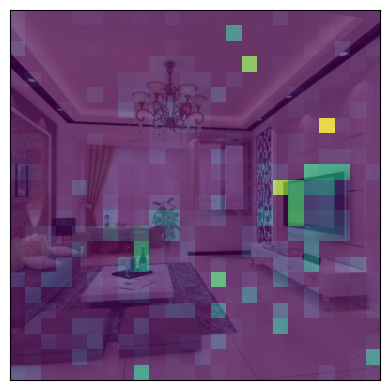

In [85]:
visualize_attention_heatmap(attn_matrix, img)